In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

#imported ALL libraries in this cell even the ones used in the last cells
# to avoid import errors in the pytest tests


In [2]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/Titanic-Dataset.csv')

In [3]:
df.isnull().sum()

ivPassengerId      0
Survived           0
Pclass             0
Name               0
Sex                0
Age              177
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           2
dtype: int64

In [4]:
df['Age'].fillna(df['Age'].median(), inplace=True)


C:\Users\mabdu\AppData\Local\Temp\ipykernel_28544\286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [5]:
df.head()

,ivPassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df['cabin_deck'] = df['Cabin'].fillna('U').astype(str).str[0]


In [7]:
df['hascabin'] = df['Cabin'].notna().astype(int)

In [8]:
df.head()

,ivPassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cabin_deck,hascabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,U,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,U,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,U,0


In [9]:
df = df.drop('Cabin', axis=1)

In [10]:
df = df.drop(['ivPassengerId', 'Name', 'Ticket', ],axis =1 )

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin_deck,hascabin
0,0,3,male,22.0,1,0,7.2500,S,U,0
1,1,1,female,38.0,1,0,71.2833,C,C,1
2,1,3,female,26.0,0,0,7.9250,S,U,0
3,1,1,female,35.0,1,0,53.1000,S,C,1
4,0,3,male,35.0,0,0,8.0500,S,U,0


In [12]:
#df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})


In [13]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin_deck,hascabin
0,0,3,male,22.0,1,0,7.2500,S,U,0
1,1,1,female,38.0,1,0,71.2833,C,C,1
2,1,3,female,26.0,0,0,7.9250,S,U,0
3,1,1,female,35.0,1,0,53.1000,S,C,1
4,0,3,male,35.0,0,0,8.0500,S,U,0


In [14]:
print (df['Sex'].unique())

['male' 'female']


In [15]:
print (df['Sex'].unique())

['male' 'female']


In [16]:
sex_encoder = LabelEncoder()
df['Sex'] = sex_encoder.fit_transform(df['Sex'])

In [17]:
deck_encoder = LabelEncoder()
df['cabin_deck'] = deck_encoder.fit_transform(df['cabin_deck'])


In [18]:
df.head(25)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin_deck,hascabin
0,0,3,1,22.0,1,0,7.2500,S,8,0
1,1,1,0,38.0,1,0,71.2833,C,2,1
2,1,3,0,26.0,0,0,7.9250,S,8,0
3,1,1,0,35.0,1,0,53.1000,S,2,1
4,0,3,1,35.0,0,0,8.0500,S,8,0
5,0,3,1,28.0,0,0,8.4583,Q,8,0
6,0,1,1,54.0,0,0,51.8625,S,4,1
7,0,3,1,2.0,3,1,21.0750,S,8,0
8,1,3,0,27.0,0,2,11.1333,S,8,0
9,1,2,0,14.0,1,0,30.0708,C,8,0


In [19]:
embarked_encoder = LabelEncoder()
df['Embarked'] =embarked_encoder.fit_transform(df['Embarked'])

In [20]:
df.head(25)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin_deck,hascabin
0,0,3,1,22.0,1,0,7.2500,2,8,0
1,1,1,0,38.0,1,0,71.2833,0,2,1
2,1,3,0,26.0,0,0,7.9250,2,8,0
3,1,1,0,35.0,1,0,53.1000,2,2,1
4,0,3,1,35.0,0,0,8.0500,2,8,0
5,0,3,1,28.0,0,0,8.4583,1,8,0
6,0,1,1,54.0,0,0,51.8625,2,4,1
7,0,3,1,2.0,3,1,21.0750,2,8,0
8,1,3,0,27.0,0,2,11.1333,2,8,0
9,1,2,0,14.0,1,0,30.0708,0,8,0


In [89]:
#encoding done now time to run the model first WITHOUT any feature selection

x = df.drop(['Survived'], axis =1)
y = df['Survived']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)



In [22]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=2))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [24]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.8511
DecisionTree testing accuracy: 0.7933
------------------------------
KNN training accuracy: 0.8750
KNN testing accuracy: 0.7989
------------------------------
Naive-Bayes training accuracy: 0.7570
Naive-Bayes testing accuracy: 0.7542
------------------------------


as you can see the accuracy is very low and now its time to work on the features and raise the accuracy

In [25]:
df.head(15)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin_deck,hascabin
0,0,3,1,22.0,1,0,7.2500,2,8,0
1,1,1,0,38.0,1,0,71.2833,0,2,1
2,1,3,0,26.0,0,0,7.9250,2,8,0
3,1,1,0,35.0,1,0,53.1000,2,2,1
4,0,3,1,35.0,0,0,8.0500,2,8,0
5,0,3,1,28.0,0,0,8.4583,1,8,0
6,0,1,1,54.0,0,0,51.8625,2,4,1
7,0,3,1,2.0,3,1,21.0750,2,8,0
8,1,3,0,27.0,0,2,11.1333,2,8,0
9,1,2,0,14.0,1,0,30.0708,0,8,0


In [26]:
correlations = df.corr()['Survived'].sort_values(ascending=False)
print (correlations)

Survived      1.000000
hascabin      0.316912
Fare          0.257307
Parch         0.081629
SibSp        -0.035322
Age          -0.064910
Embarked     -0.163517
cabin_deck   -0.301116
Pclass       -0.338481
Sex          -0.543351
Name: Survived, dtype: float64


we realize that cabin deck and sex are pivotal in the model other featured need to be modified


In [27]:
survivedbycabin = df.groupby('hascabin')['Survived'].mean()
print("Survival rate by cabin presence (0 = No Cabin, 1 = Has Cabin):")
print(survivedbycabin)


# Survival rate for each cabin deck
if 'cabin_deck' in df.columns:
    survivedbydeck = df.groupby('cabin_deck')['Survived'].mean().sort_index()
    print("\nSurvival rate by cabin deck:")
    print(survivedbydeck)
else:
    print("Column 'cabin_deck' not found in DataFrame.")

Survival rate by cabin presence (0 = No Cabin, 1 = Has Cabin):
hascabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Survival rate by cabin deck:
cabin_deck
0    0.466667
1    0.744681
2    0.593220
3    0.757576
4    0.750000
5    0.615385
6    0.500000
7    0.000000
8    0.299854
Name: Survived, dtype: float64


further solidifies our claim with statistics showing a 66.7% of passengers in cabin survived 
cabin decks survival rates are also shown


C:\Users\mabdu\AppData\Local\Temp\ipykernel_28544\778517756.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='hascabin', y='Survived', data=df, ci=None, palette='pastel')
C:\Users\mabdu\AppData\Local\Temp\ipykernel_28544\778517756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hascabin', y='Survived', data=df, ci=None, palette='pastel')


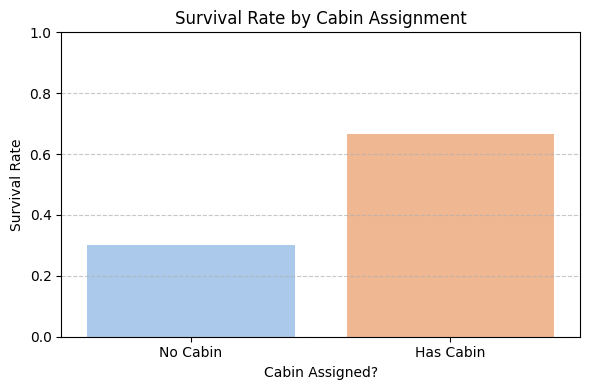

C:\Users\mabdu\AppData\Local\Temp\ipykernel_28544\778517756.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='cabin_deck', y='Survived', data=df, ci=None, order=sorted(df['cabin_deck'].unique()), palette='muted')
C:\Users\mabdu\AppData\Local\Temp\ipykernel_28544\778517756.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cabin_deck', y='Survived', data=df, ci=None, order=sorted(df['cabin_deck'].unique()), palette='muted')


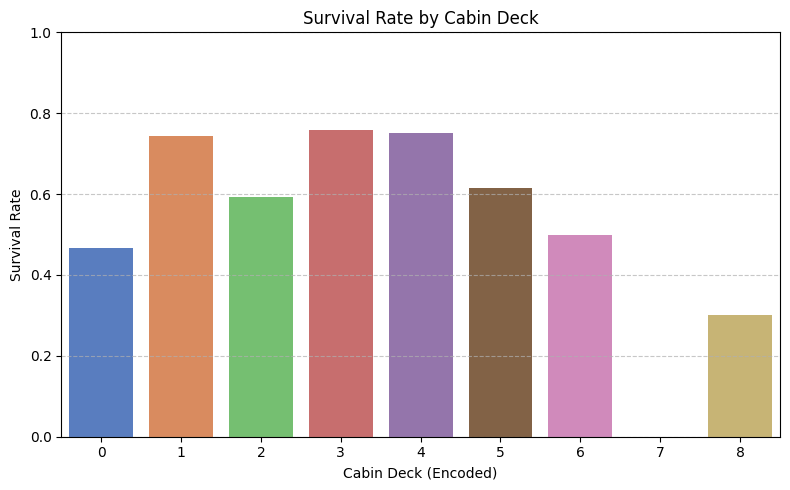

In [28]:
plt.figure(figsize=(6, 4))
sns.barplot(x='hascabin', y='Survived', data=df, ci=None, palette='pastel')

plt.xticks([0, 1], ['No Cabin', 'Has Cabin'])
plt.title("Survival Rate by Cabin Assignment")
plt.ylabel("Survival Rate")
plt.xlabel("Cabin Assigned?")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='cabin_deck', y='Survived', data=df, ci=None, order=sorted(df['cabin_deck'].unique()), palette='muted')

plt.title("Survival Rate by Cabin Deck")
plt.ylabel("Survival Rate")
plt.xlabel("Cabin Deck (Encoded)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

sibling spouse and family size individually have a low correlation however a feature of family size might have a higher correlation to survival since families are prioritized in a state of emergency

In [29]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Alone'] = (df['FamilySize'] == 1).astype(int)




In [30]:
df.groupby('FamilySize')['Survived'].mean()


FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [31]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin_deck,hascabin,FamilySize,Alone
0,0,3,1,22.0,1,0,7.2500,2,8,0,2,0
1,1,1,0,38.0,1,0,71.2833,0,2,1,2,0
2,1,3,0,26.0,0,0,7.9250,2,8,0,1,1
3,1,1,0,35.0,1,0,53.1000,2,2,1,2,0
4,0,3,1,35.0,0,0,8.0500,2,8,0,1,1


In [32]:
correlations = df.corr()['Survived'].sort_values(ascending=False)
print (correlations)

Survived      1.000000
hascabin      0.316912
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
Embarked     -0.163517
Alone        -0.203367
cabin_deck   -0.301116
Pclass       -0.338481
Sex          -0.543351
Name: Survived, dtype: float64


In [ ]:
#running models after some feature engineering

x = df.drop(['Survived'], axis =1)
y = df['Survived']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)

     Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  cabin_deck  hascabin  \
0         3    1  22.0      1      0   7.2500         2           8         0   
1         1    0  38.0      1      0  71.2833         0           2         1   
2         3    0  26.0      0      0   7.9250         2           8         0   
3         1    0  35.0      1      0  53.1000         2           2         1   
4         3    1  35.0      0      0   8.0500         2           8         0   
..      ...  ...   ...    ...    ...      ...       ...         ...       ...   
886       2    1  27.0      0      0  13.0000         2           8         0   
887       1    0  19.0      0      0  30.0000         2           1         1   
888       3    0  28.0      1      2  23.4500         2           8         0   
889       1    1  26.0      0      0  30.0000         0           2         1   
890       3    1  32.0      0      0   7.7500         1           8         0   

     FamilySize  Alone  
0 

In [34]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=6))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}


In [35]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [36]:
'''
k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    pipeline = Pipeline([
        ('scalar', StandardScaler()),
        ('clf', knn)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"K={k}: Test Accuracy = {score:.4f}")

best_k = k_range[scores.index(max(scores))]
print(f"Best K: {best_k} with accuracy {max(scores):.4f}")
'''

'\nk_range = range(1, 21)\nscores = []\n\nfor k in k_range:\n    knn = KNeighborsClassifier(n_neighbors=k)\n    pipeline = Pipeline([\n        (\'scalar\', StandardScaler()),\n        (\'clf\', knn)\n    ])\n    pipeline.fit(X_train, y_train)\n    score = pipeline.score(X_test, y_test)\n    scores.append(score)\n    print(f"K={k}: Test Accuracy = {score:.4f}")\n\nbest_k = k_range[scores.index(max(scores))]\nprint(f"Best K: {best_k} with accuracy {max(scores):.4f}")\n'

In [37]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.8919
DecisionTree testing accuracy: 0.8212
------------------------------
KNN training accuracy: 0.8455
KNN testing accuracy: 0.8268
------------------------------
Naive-Bayes training accuracy: 0.7584
Naive-Bayes testing accuracy: 0.7542
------------------------------


BEFORE

DecisionTree training accuracy: 0.8511
DecisionTree testing accuracy: 0.7933
------------------------------
KNN training accuracy: 0.8750
KNN testing accuracy: 0.7989
------------------------------
Naive-Bayes training accuracy: 0.7570
Naive-Bayes testing accuracy: 0.7542

SLIGHT CHANGES BASED PURELY ON CORRELATION FACTOR

DECISON TREE increases from 0.79 to 0.8101
KNN increases from 0.79 to 0.8212
Naive Bayes increases from 0.7542 to 0.7989



In [59]:
#A brute force attempt to remove further features to get a higher accuracy BASED PURELY ON COMMON SENSE


In [60]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,cabin_deck,hascabin,FamilySize
0,0,3,1,22.0,1,0,8,0,2
1,1,1,0,38.0,1,0,2,1,2
2,1,3,0,26.0,0,0,8,0,1
3,1,1,0,35.0,1,0,2,1,2
4,0,3,1,35.0,0,0,8,0,1


In [68]:
#df = df.drop('Alone', axis = 1) #since family size 1 infers that a person was alone no need for another feature reducing memory
#df = df.drop('Fare', axis=1) #despite a better correlation i dont see how fare can affect chances of survival
#df= df.drop('Embarked',axis =1) #doesnt matter where u board from lahore, queenstown or southampton ur chances of survival should not matter


In [70]:
df = df.drop(['SibSp', 'Parch'],axis=1)

In [71]:
df.head()

,Survived,Pclass,Sex,Age,cabin_deck,hascabin,FamilySize
0,0,3,1,22.0,8,0,2
1,1,1,0,38.0,2,1,2
2,1,3,0,26.0,8,0,1
3,1,1,0,35.0,2,1,2
4,0,3,1,35.0,8,0,1


In [72]:
#runnning model again (might overfit)

x = df.drop(['Survived'], axis =1)
y = df['Survived']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)


     Pclass  Sex   Age  cabin_deck  hascabin  FamilySize
0         3    1  22.0           8         0           2
1         1    0  38.0           2         1           2
2         3    0  26.0           8         0           1
3         1    0  35.0           2         1           2
4         3    1  35.0           8         0           1
..      ...  ...   ...         ...       ...         ...
886       2    1  27.0           8         0           1
887       1    0  19.0           1         1           1
888       3    0  28.0           8         0           4
889       1    1  26.0           2         1           1
890       3    1  32.0           8         0           1

[891 rows x 6 columns]


In [78]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=2))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}


In [83]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [84]:
'''
k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    pipeline = Pipeline([
        ('scalar', StandardScaler()),
        ('clf', knn)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"K={k}: Test Accuracy = {score:.4f}")

best_k = k_range[scores.index(max(scores))]
print(f"Best K: {best_k} with accuracy {max(scores):.4f}")
'''

'\nk_range = range(1, 21)\nscores = []\n\nfor k in k_range:\n    knn = KNeighborsClassifier(n_neighbors=k)\n    pipeline = Pipeline([\n        (\'scalar\', StandardScaler()),\n        (\'clf\', knn)\n    ])\n    pipeline.fit(X_train, y_train)\n    score = pipeline.score(X_test, y_test)\n    scores.append(score)\n    print(f"K={k}: Test Accuracy = {score:.4f}")\n\nbest_k = k_range[scores.index(max(scores))]\nprint(f"Best K: {best_k} with accuracy {max(scores):.4f}")\n'

In [85]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.8413
DecisionTree testing accuracy: 0.8101
------------------------------
KNN training accuracy: 0.8680
KNN testing accuracy: 0.8045
------------------------------
Naive-Bayes training accuracy: 0.7865
Naive-Bayes testing accuracy: 0.7933
------------------------------


AFTER FEATURE ENGINEERING AND SELECTION BASED ON CORRELATION

DecisionTree training accuracy: 0.8933
DecisionTree testing accuracy: 0.8101
------------------------------
KNN training accuracy: 0.8581
KNN testing accuracy: 0.8212
------------------------------
Naive-Bayes training accuracy: 0.7570
Naive-Bayes testing accuracy: 0.7598

decision tree remains the same (.8101)
KNN decreases from .8212 to 8045
Naive-Bayes increases significantly from 0.7598 to 0.7933

## Model Evaluation After Feature Engineering & Selection
Below are the classification reports, confusion matrices, and metric graphs for all models after feature engineering and selection.

Classification Report for DecisionTree (After FE&Selection):
              precision    recall  f1-score   support

           0     0.8087    0.8857    0.8455       105
           1     0.8125    0.7027    0.7536        74

    accuracy                         0.8101       179
   macro avg     0.8106    0.7942    0.7995       179
weighted avg     0.8103    0.8101    0.8075       179

----------------------------------------
Classification Report for KNN (After FE&Selection):
              precision    recall  f1-score   support

           0     0.7966    0.8952    0.8430       105
           1     0.8197    0.6757    0.7407        74

    accuracy                         0.8045       179
   macro avg     0.8081    0.7855    0.7919       179
weighted avg     0.8061    0.8045    0.8008       179

----------------------------------------
Classification Report for Naive-Bayes (After FE&Selection):
              precision    recall  f1-score   support

           0     0.8617    0.7714   

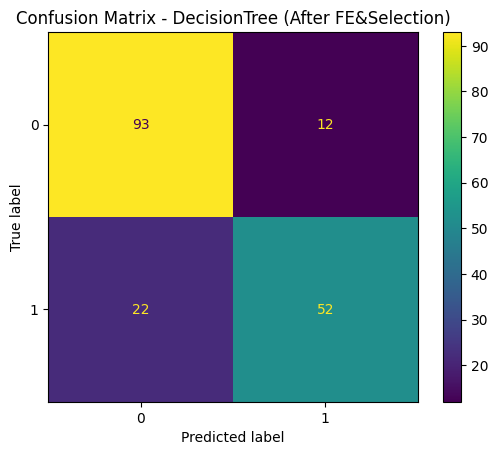

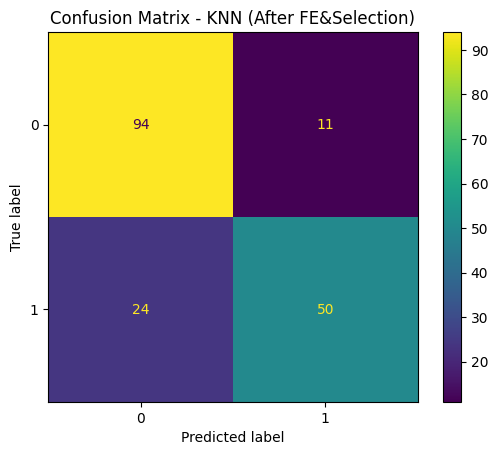

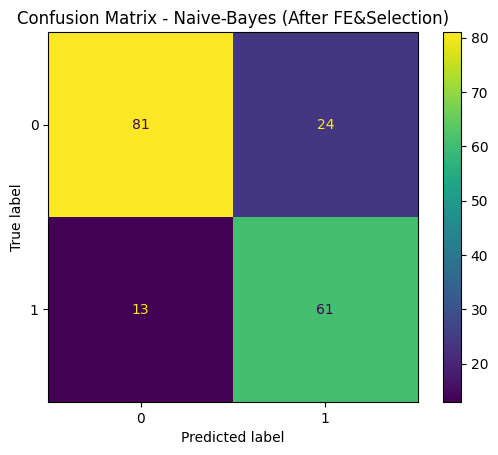

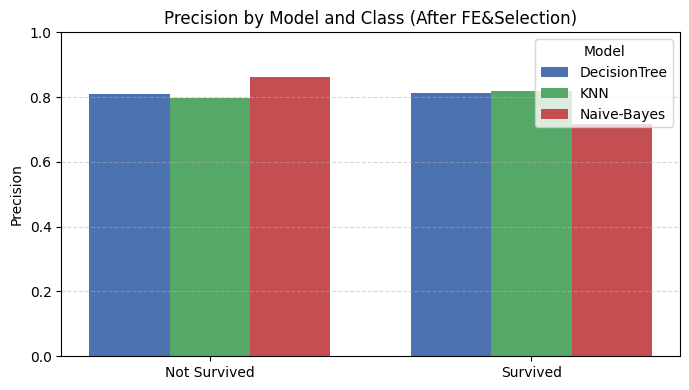

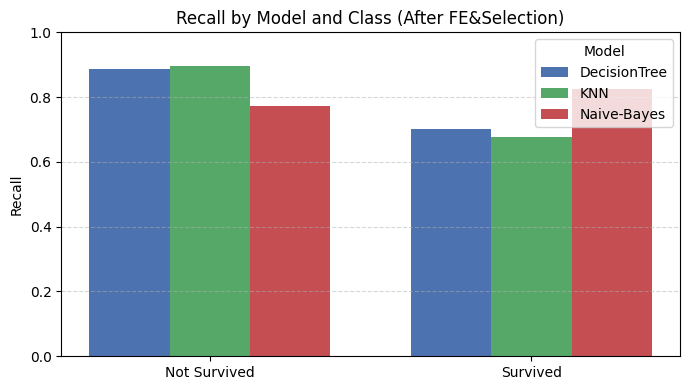

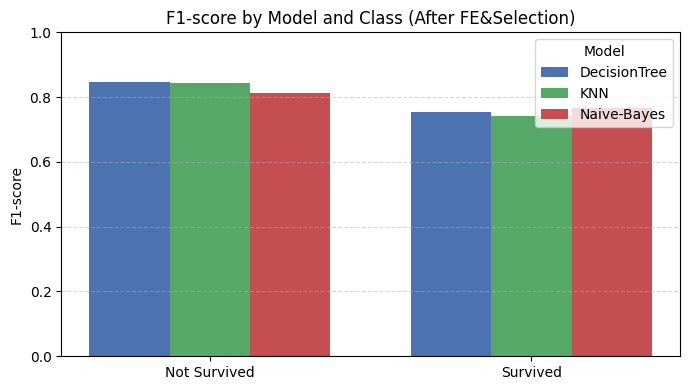

Support (number of samples per class in test set):
              DecisionTree  KNN  Naive-Bayes
Not Survived           105  105          105
Survived                74   74           74


In [87]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Evaluate all models after FE&Selection
model_reports = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"Classification Report for {name} (After FE&Selection):")
    print(classification_report(y_test, y_pred, digits=4))
    print("-" * 40)
    model_reports[name] = classification_report(y_test, y_pred, output_dict=True)

# Confusion matrices for all models
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name} (After FE&Selection)")
    plt.show()

# Individual metric bar graphs for all models
classes = ['0', '1']
class_names = ['Not Survived', 'Survived']
metrics = ['precision', 'recall', 'f1-score']
colors = ['#4C72B0', '#55A868', '#C44E52']

for metric in metrics:
    plt.figure(figsize=(7, 4))
    for idx, (model_name, report) in enumerate(model_reports.items()):
        values = [report[cls][metric] for cls in classes]
        plt.bar(np.arange(len(classes)) + 0.25 * idx, values, width=0.25, label=model_name, color=colors[idx])
    plt.xticks(np.arange(len(classes)) + 0.25, class_names)
    plt.ylim(0, 1)
    plt.ylabel(metric.capitalize())
    plt.title(f'{metric.capitalize()} by Model and Class (After FE&Selection)')
    plt.legend(title='Model')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Show support as a table for clarity
support_data = {model: [int(model_reports[model][cls]['support']) for cls in classes] for model in model_reports}
support_df = pd.DataFrame(support_data, index=class_names)
print('Support (number of samples per class in test set):')
print(support_df)


In [ ]:
#select a model for prediction

